# Thử nghiệm mô hình ensemble - lần 1

Notebook này so sánh vài mô hình hồi quy đơn lẻ với một mô hình ensemble để dự đoán tuổi Abalone.

## 1. Import thư viện

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

## 2. Nạp dữ liệu và kiểm tra nhanh

In [ ]:
đường_dẫn_ứng_viên = [
    Path('../../data/raw/abalone.csv'),
    Path('../data/raw/abalone.csv'),
    Path('data/raw/abalone.csv'),
    Path('AbaloneAge/data/raw/abalone.csv'),
]

đường_dẫn_dữ_liệu = None
for p in đường_dẫn_ứng_viên:
    p_đầy_đủ = p.resolve()
    if p_đầy_đủ.exists():
        đường_dẫn_dữ_liệu = p_đầy_đủ
        break

if đường_dẫn_dữ_liệu is None:
    raise FileNotFoundError(
        'Không tìm thấy file abalone.csv. Đã thử: ' + ', '.join(str(p.resolve()) for p in đường_dẫn_ứng_viên)
    )

df = pd.read_csv(đường_dẫn_dữ_liệu, header=None)
df.columns = [
    'sex', 'length', 'diameter', 'height',
    'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'rings'
]

print('Đường dẫn dữ liệu:', đường_dẫn_dữ_liệu)
print('Kích thước:', df.shape)
print('Số giá trị thiếu:')
print(df.isnull().sum())
df.head()

Duong dan du lieu: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\data\raw\abalone.csv
Kich thuoc: (4177, 9)
So gia tri thieu:
sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Chia train, validation, test

In [3]:
X = df.drop(columns=['rings'])
y = df['rings']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

Train: (2923, 8) (2923,)
Validation: (627, 8) (627,)
Test: (627, 8) (627,)


## 4. Tiền xử lý chung

In [ ]:
cột_số = ['length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight']
cột_hạng_mục = ['sex']

tiền_xử_lý = ColumnTransformer(transformers=[
    ('so', Pipeline(steps=[
        ('dien_khuyet', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ]), cột_số),
    ('hang_muc', Pipeline(steps=[
        ('dien_khuyet', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(handle_unknown='ignore')),
    ]), cột_hạng_mục),
])

X_train_txl = tiền_xử_lý.fit_transform(X_train)
X_val_txl = tiền_xử_lý.transform(X_val)
X_test_txl = tiền_xử_lý.transform(X_test)

tên_đặc_trưng = tiền_xử_lý.get_feature_names_out()
print('Số đặc trưng sau tiền xử lý:', len(tên_đặc_trưng))

So dac trung sau tien xu ly: 10


## 5. Huấn luyện các mô hình đơn lẻ

In [ ]:
mô_hình_dict = {
    'ridge': Ridge(alpha=1.0),
    'linear_regression': LinearRegression(),
    'random_forest': RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    'extra_trees': ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    'gradient_boosting': GradientBoostingRegressor(random_state=42),
}

kết_quả = []
mô_hình_đã_train = {}

for tên, mô_hình in mô_hình_dict.items():
    mô_hình.fit(X_train_txl, y_train)
    dự_đoán_val = mô_hình.predict(X_val_txl)

    mae = mean_absolute_error(y_val, dự_đoán_val)
    rmse = np.sqrt(mean_squared_error(y_val, dự_đoán_val))
    r2 = r2_score(y_val, dự_đoán_val)

    kết_quả.append({
        'mô_hình': tên,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
    })
    mô_hình_đã_train[tên] = mô_hình

bảng_kết_quả = pd.DataFrame(kết_quả).sort_values(by='RMSE')
bảng_kết_quả

,mo_hinh,MAE,RMSE,R2
0,ridge,1.620732,2.224273,0.506883
1,linear_regression,1.621848,2.228053,0.505206
4,gradient_boosting,1.590471,2.248320,0.496163
2,random_forest,1.594844,2.269166,0.486777
3,extra_trees,1.611240,2.289981,0.477318


## 6. Xây mô hình ensemble

In [ ]:
ensemble = VotingRegressor(estimators=[
    ('ridge', Ridge(alpha=1.0)),
    ('rf', RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
    ('et', ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingRegressor(random_state=42)),
])

ensemble.fit(X_train_txl, y_train)
dự_đoán_val_ensemble = ensemble.predict(X_val_txl)

mae_ens = mean_absolute_error(y_val, dự_đoán_val_ensemble)
rmse_ens = np.sqrt(mean_squared_error(y_val, dự_đoán_val_ensemble))
r2_ens = r2_score(y_val, dự_đoán_val_ensemble)

bảng_ensemble = pd.DataFrame([
    {'mô_hình': 'voting_ensemble', 'MAE': mae_ens, 'RMSE': rmse_ens, 'R2': r2_ens}
])

bảng_so_sánh = pd.concat([bảng_kết_quả, bảng_ensemble], ignore_index=True).sort_values(by='RMSE')
bảng_so_sánh

,mo_hinh,MAE,RMSE,R2
5,voting_ensemble,1.549685,2.192640,0.520809
0,ridge,1.620732,2.224273,0.506883
1,linear_regression,1.621848,2.228053,0.505206
2,gradient_boosting,1.590471,2.248320,0.496163
3,random_forest,1.594844,2.269166,0.486777
4,extra_trees,1.611240,2.289981,0.477318


## 7. Trực quan hóa so sánh

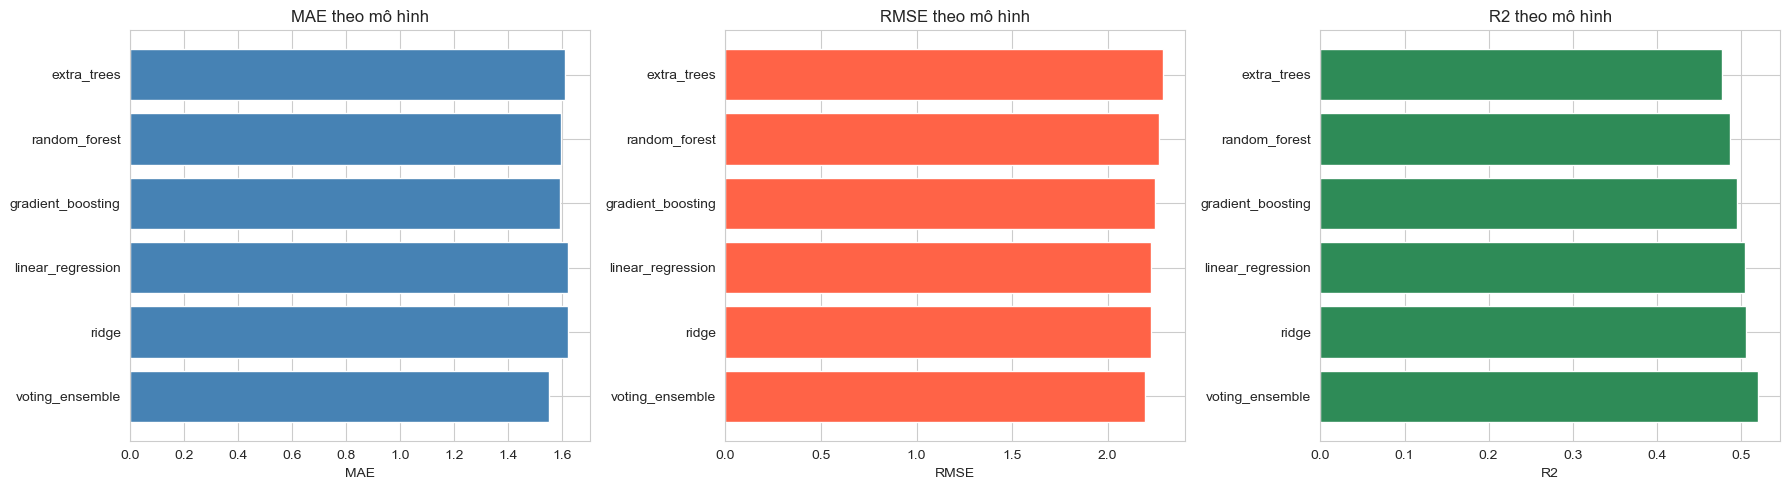

Da luu hinh: 04_model_ensemble_try1_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(bảng_so_sánh['mô_hình'], bảng_so_sánh['MAE'], color='steelblue')
axes[0].set_title('MAE theo mô hình')
axes[0].set_xlabel('MAE')

axes[1].barh(bảng_so_sánh['mô_hình'], bảng_so_sánh['RMSE'], color='tomato')
axes[1].set_title('RMSE theo mô hình')
axes[1].set_xlabel('RMSE')

axes[2].barh(bảng_so_sánh['mô_hình'], bảng_so_sánh['R2'], color='seagreen')
axes[2].set_title('R2 theo mô hình')
axes[2].set_xlabel('R2')

plt.tight_layout()
thư_mục_hình = Path('../../outputs/figures').resolve()
thư_mục_hình.mkdir(parents=True, exist_ok=True)
plt.savefig(thư_mục_hình / '04_model_ensemble_try1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Đã lưu hình: 04_model_ensemble_try1_comparison.png')

## 8. Đánh giá trên tập test

In [ ]:
mô_hình_tốt_nhất = bảng_so_sánh.iloc[0]['mô_hình']
print('Mô hình tốt nhất theo validation:', mô_hình_tốt_nhất)

if mô_hình_tốt_nhất == 'voting_ensemble':
    mô_hình_cuối = ensemble
else:
    mô_hình_cuối = mô_hình_đã_train[mô_hình_tốt_nhất]

dự_đoán_test = mô_hình_cuối.predict(X_test_txl)
mae_test = mean_absolute_error(y_test, dự_đoán_test)
rmse_test = np.sqrt(mean_squared_error(y_test, dự_đoán_test))
r2_test = r2_score(y_test, dự_đoán_test)

print(f'MAE test : {mae_test:.4f}')
print(f'RMSE test: {rmse_test:.4f}')
print(f'R2 test  : {r2_test:.4f}')

Mo hinh tot nhat theo validation: voting_ensemble
MAE test : 1.4678
RMSE test: 2.0553
R2 test  : 0.5884


## 9. Lưu kết quả

In [ ]:
thư_mục_metrics = Path('../../outputs/metrics').resolve()
thư_mục_metrics.mkdir(parents=True, exist_ok=True)

bảng_so_sánh.to_csv(thư_mục_metrics / '04_model_ensemble_try1_comparison.csv', index=False)

tổng_tắt = {
    'phương_pháp': 'ensemble_try1',
    'mô_hình_tốt_nhất': mô_hình_tốt_nhất,
    'validation': bảng_so_sánh.iloc[0].to_dict(),
    'test': {
        'MAE': mae_test,
        'RMSE': rmse_test,
        'R2': r2_test,
    },
}

with open(thư_mục_metrics / '04_model_ensemble_try1_summary.json', 'w', encoding='utf-8') as f:
    json.dump(tổng_tắt, f, ensure_ascii=False, indent=2)

print('Đã lưu: 04_model_ensemble_try1_comparison.csv')
print('Đã lưu: 04_model_ensemble_try1_summary.json')

Da luu: 04_model_ensemble_try1_comparison.csv
Da luu: 04_model_ensemble_try1_summary.json
